In [14]:
import pandas as pd

# Telemetry of the fastest qualifying lap for each driver (2024 Miami GP)
df = pd.read_csv("miami2024_q_sainz_leclerc.csv")

sai = df[df["Driver"] == "SAI"]   # Sainz's lap
lec = df[df["Driver"] == "LEC"]   # Leclerc's lap

print("Loaded:", df.shape[0], "telemetry points")
print("Sainz  :", sai["LapTime"].iloc[0], "|", len(sai), "points")
print("Leclerc:", lec["LapTime"].iloc[0], "|", len(lec), "points")

Loaded: 1331 telemetry points
Sainz  : 0 days 00:01:27.455000 | 662 points
Leclerc: 0 days 00:01:27.382000 | 669 points


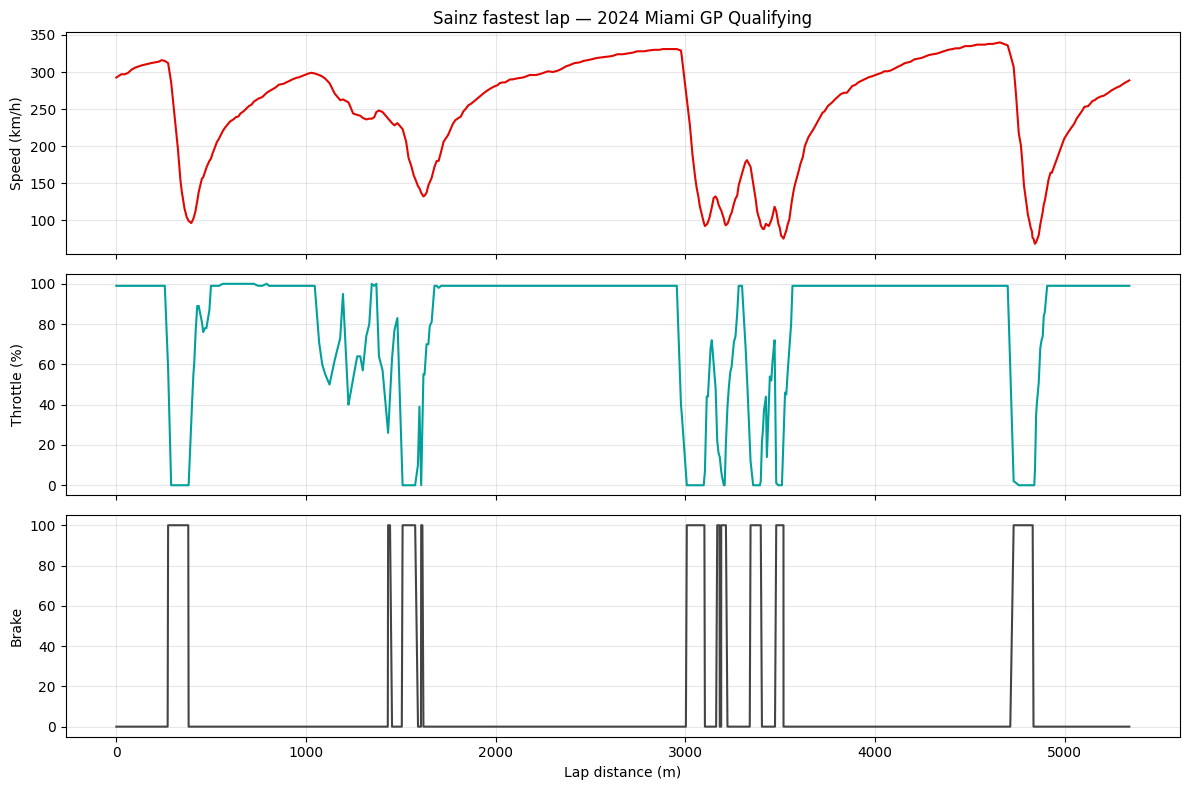

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

ax[0].plot(sai["Distance"], sai["Speed"], color="#e10600")
ax[0].set_ylabel("Speed (km/h)")
ax[0].set_title("Sainz fastest lap — 2024 Miami GP Qualifying")

ax[1].plot(sai["Distance"], sai["Throttle"], color="#00a19c")
ax[1].set_ylabel("Throttle (%)")

ax[2].plot(sai["Distance"], sai["Brake"].astype(int) * 100, color="#444")
ax[2].set_ylabel("Brake")
ax[2].set_xlabel("Lap distance (m)")

for a in ax:
    a.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

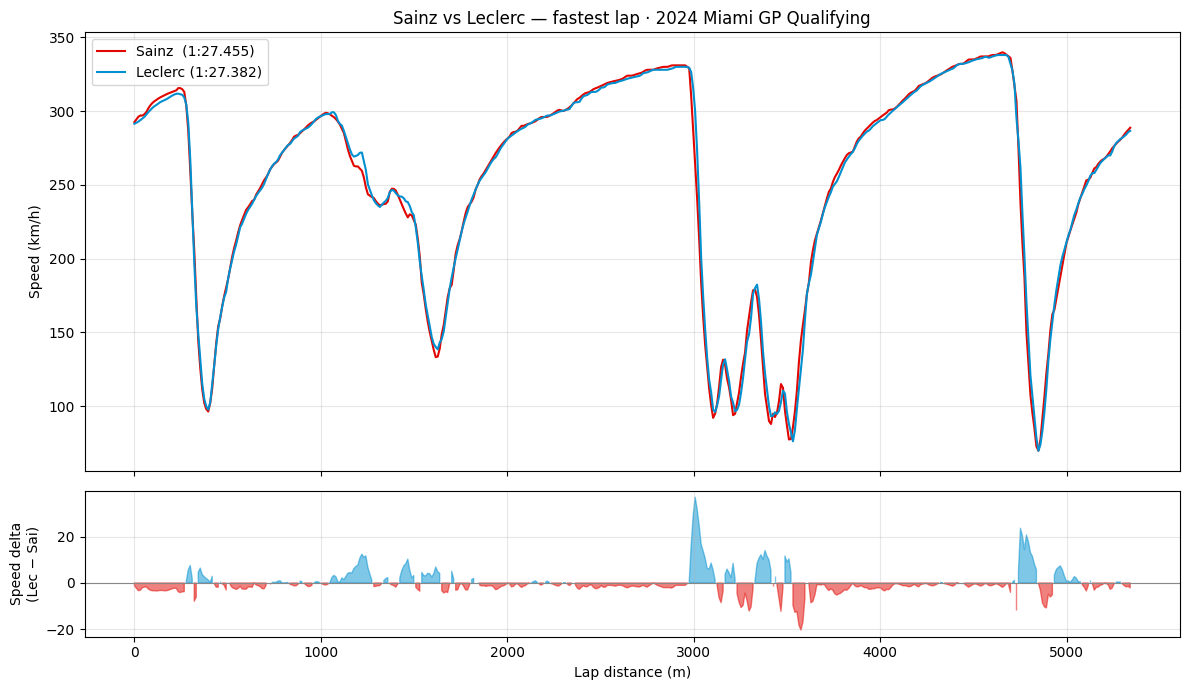

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Resample both drivers onto the same distance base for a point-by-point comparison
dist  = np.linspace(0, min(sai["Distance"].max(), lec["Distance"].max()), 500)
v_sai = np.interp(dist, sai["Distance"], sai["Speed"])
v_lec = np.interp(dist, lec["Distance"], lec["Speed"])

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1]})

ax[0].plot(dist, v_sai, color="#e10600", label="Sainz  (1:27.455)")
ax[0].plot(dist, v_lec, color="#0090d0", label="Leclerc (1:27.382)")
ax[0].set_ylabel("Speed (km/h)")
ax[0].set_title("Sainz vs Leclerc — fastest lap · 2024 Miami GP Qualifying")
ax[0].legend(); ax[0].grid(True, alpha=0.3)

# Blue = Leclerc faster, Red = Sainz faster
dv = v_lec - v_sai
ax[1].fill_between(dist, dv, 0, where=dv >= 0, color="#0090d0", alpha=0.5)
ax[1].fill_between(dist, dv, 0, where=dv <  0, color="#e10600", alpha=0.5)
ax[1].axhline(0, color="#888", lw=0.8)
ax[1].set_ylabel("Speed delta\n(Lec − Sai)")
ax[1].set_xlabel("Lap distance (m)")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

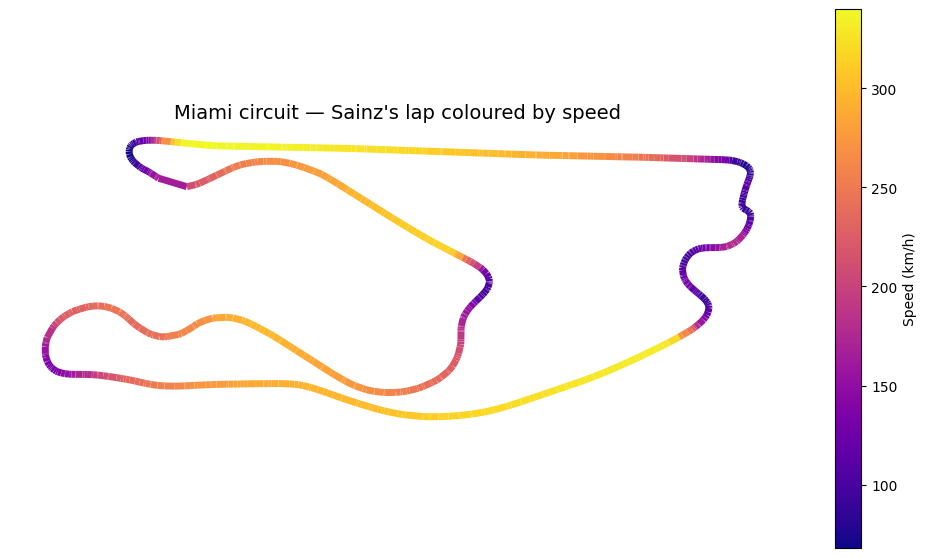

In [17]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

x = sai["X"].to_numpy()
y = sai["Y"].to_numpy()
speed = sai["Speed"].to_numpy()

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

fig, ax = plt.subplots(figsize=(10, 8))
lc = LineCollection(segments, cmap="plasma", linewidth=5)
lc.set_array(speed)
ax.add_collection(lc)
ax.autoscale()
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Miami circuit — Sainz's lap coloured by speed", fontsize=14)

cbar = fig.colorbar(lc, ax=ax, shrink=0.7)
cbar.set_label("Speed (km/h)")

plt.tight_layout()
plt.show()